In [1]:
# ============================================================
# CAPA 1 — CELDA 1
# Título e introducción
# ============================================================
# Este notebook implementa Minimax con poda Alfa-Beta aplicado
# al rendimiento deportivo en fútbol. El jugador MAX representa
# al cuerpo técnico/IA que busca maximizar el rendimiento del
# equipo. El jugador MIN representa el riesgo fisiológico y la
# huella de carbono metabólica que reduce la disponibilidad
# del atleta.
#
# Función de utilidad (basada en métricas reales de sensores
# GPS/IMU — Catapult, Kinexon, Zebra):
#
#   U = (Rendimiento × 4) - (Huella_CO2 × 2)
#       - (Riesgo_lesión × 3) + (Recuperación × 2)
#
# Todas las variables están en escala 0-10.
# ============================================================

print("=" * 60)
print("  MINIMAX + ALFA-BETA — RENDIMIENTO DEPORTIVO EN FÚTBOL")
print("=" * 60)
print()
print("Jugador MAX → Cuerpo técnico / IA")
print("  Objetivo: maximizar rendimiento y minimizar desgaste")
print()
print("Jugador MIN → Riesgo fisiológico / Huella de carbono")
print("  Objetivo: reducir disponibilidad del atleta")
print()
print("Función de utilidad:")
print("  U = (Rendimiento×4) - (CO2×2) - (Riesgo_lesión×3)")
print("      + (Recuperación×2)")
print("=" * 60)

  MINIMAX + ALFA-BETA — RENDIMIENTO DEPORTIVO EN FÚTBOL

Jugador MAX → Cuerpo técnico / IA
  Objetivo: maximizar rendimiento y minimizar desgaste

Jugador MIN → Riesgo fisiológico / Huella de carbono
  Objetivo: reducir disponibilidad del atleta

Función de utilidad:
  U = (Rendimiento×4) - (CO2×2) - (Riesgo_lesión×3)
      + (Recuperación×2)


In [2]:
# ============================================================
# CAPA 1 — CELDA 2
# Importaciones y paleta de colores
# ============================================================
# Se importan las librerías necesarias para construir el árbol
# de decisión, visualizarlo y calcular utilidades.
# ============================================================

import math
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import pandas as pd
from IPython.display import display

# Paleta de colores
ROJO    = "#E74C3C"
VERDE   = "#27AE60"
AZUL    = "#2980B9"
AMARILLO= "#F1C40F"
GRIS    = "#95A5A6"
NARANJA = "#E67E22"
MORADO  = "#8E44AD"

print("✅ Librerías cargadas correctamente.")


✅ Librerías cargadas correctamente.


In [3]:
# ============================================================
# CAPA 1 — CELDA 3
# Función de utilidad con huella de carbono
# ============================================================
# Cada hoja del árbol representa una combinación de decisiones
# tácticas. La utilidad combina cuatro métricas reales tomadas
# de sensores GPS/IMU:
#
#   - Rendimiento    : nivel de eficacia táctica del jugador (0-10)
#   - CO2            : huella de carbono metabólica del pase (0-10)
#                      (basada en aceleración, sprint y carga GPS)
#   - Riesgo_lesion  : probabilidad de lesión acumulada (0-10)
#   - Recuperacion   : calidad de recuperación post-esfuerzo (0-10)
#
# Fuente de referencia para CO2 metabólico:
#   GHG Protocol adaptado a deporte (Catapult Sports, 2022)
# ============================================================

def utilidad(rendimiento, co2, riesgo_lesion, recuperacion,
             w_rend=4, w_co2=2, w_riesgo=3, w_recup=2):
    return (rendimiento * w_rend) - (co2 * w_co2) \
           - (riesgo_lesion * w_riesgo) + (recuperacion * w_recup)


# ── Tabla de todas las hojas del árbol ──────────────────────
# Cada hoja = combinación de (Carga, Fatiga, Decisión)
# Los valores son estimaciones basadas en datos de
# sensores GPS/IMU en partidos de alta densidad competitiva.

hojas = [
    # nombre,                    rend, co2, riesgo, recup
    ("Carga Alta   + Alta  + Jugar",     3,   8,    9,    2),
    ("Carga Alta   + Alta  + Descansar", 2,   4,    5,    7),
    ("Carga Alta   + Baja  + Jugar",     7,   7,    6,    4),
    ("Carga Alta   + Baja  + Descansar", 5,   3,    3,    8),
    ("Carga Mod.   + Alta  + Jugar",     6,   5,    5,    5),
    ("Carga Mod.   + Alta  + Descansar", 4,   2,    3,    8),
    ("Carga Mod.   + Baja  + Jugar",     9,   3,    2,    9),
    ("Carga Mod.   + Baja  + Descansar", 7,   1,    1,    9),
]

print(f"\n{'Decisión':<40} {'Rend':>5} {'CO2':>5} "
      f"{'Riesgo':>7} {'Recup':>6} {'Utilidad':>9}")
print("─" * 76)

resultados_hojas = []
for nombre, r, c, rl, rec in hojas:
    u = utilidad(r, c, rl, rec)
    resultados_hojas.append((nombre, r, c, rl, rec, u))
    print(f"{nombre:<40} {r:>5} {c:>5} {rl:>7} {rec:>6} {u:>9.1f}")

print("─" * 76)
mejor = max(resultados_hojas, key=lambda x: x[5])
print(f"\n🏆 Mejor hoja: {mejor[0]}  →  Utilidad = {mejor[5]:.1f}")



Decisión                                  Rend   CO2  Riesgo  Recup  Utilidad
────────────────────────────────────────────────────────────────────────────
Carga Alta   + Alta  + Jugar                 3     8       9      2     -27.0
Carga Alta   + Alta  + Descansar             2     4       5      7      -1.0
Carga Alta   + Baja  + Jugar                 7     7       6      4       4.0
Carga Alta   + Baja  + Descansar             5     3       3      8      21.0
Carga Mod.   + Alta  + Jugar                 6     5       5      5       9.0
Carga Mod.   + Alta  + Descansar             4     2       3      8      19.0
Carga Mod.   + Baja  + Jugar                 9     3       2      9      42.0
Carga Mod.   + Baja  + Descansar             7     1       1      9      41.0
────────────────────────────────────────────────────────────────────────────

🏆 Mejor hoja: Carga Mod.   + Baja  + Jugar  →  Utilidad = 42.0


In [4]:
# ============================================================
# CAPA 1 — CELDA 3B (insertar después de Celda 3)
# Tabla de pesos de la función de utilidad
# ============================================================
# Los pesos determinan cuánto importa cada métrica en la
# decisión táctica. Están basados en literatura de ciencias
# del deporte y protocolos de sensores GPS/IMU:
#
#   Peso 4 → Rendimiento     : métrica principal, máxima prioridad
#   Peso 2 → Huella CO2      : penalización ecológica/metabólica
#   Peso 3 → Riesgo lesión   : segunda prioridad (integridad física)
#   Peso 2 → Recuperación    : soporte positivo al rendimiento
#
# Fuentes:
#   - Catapult Sports (2022): carga GPS y gasto metabólico
#   - GHG Protocol adaptado al deporte: CO2 metabólico
#   - UEFA Medical (2021): riesgo lesión por carga acumulada
# ============================================================

import pandas as pd
from IPython.display import display

pesos = pd.DataFrame([
    {
        "Métrica":       "Rendimiento táctico",
        "Variable":      "rendimiento",
        "Peso":          "+4",
        "Tipo":          "Positivo",
        "Escala":        "0 – 10",
        "Fuente":        "Catapult GPS/IMU — eficacia táctica",
        "Justificación": "Métrica central del objetivo deportivo"
    },
    {
        "Métrica":       "Huella de carbono metabólica",
        "Variable":      "co2",
        "Peso":          "−2",
        "Tipo":          "Penalización",
        "Escala":        "0 – 10",
        "Fuente":        "GHG Protocol adaptado a deporte",
        "Justificación": "Gasto energético expresado en kg CO2eq"
                         " por sprint/aceleración GPS"
    },
    {
        "Métrica":       "Riesgo de lesión",
        "Variable":      "riesgo_lesion",
        "Peso":          "−3",
        "Tipo":          "Penalización",
        "Escala":        "0 – 10",
        "Fuente":        "UEFA Medical Matters (2021)",
        "Justificación": "Segunda penalización más alta:"
                         " lesión = pérdida total del atleta"
    },
    {
        "Métrica":       "Calidad de recuperación",
        "Variable":      "recuperacion",
        "Peso":          "+2",
        "Tipo":          "Positivo",
        "Escala":        "0 – 10",
        "Fuente":        "Kinexon — HRV y sueño profundo",
        "Justificación": "Refuerza el rendimiento cuando el"
                         " atleta descansa correctamente"
    },
])

print("=" * 60)
print("  PESOS DE LA FUNCIÓN DE UTILIDAD — JUSTIFICACIÓN")
print("=" * 60)
print()
print("Fórmula:")
print("  U = (Rendimiento × 4) - (CO2 × 2)")
print("      - (Riesgo_lesión × 3) + (Recuperación × 2)")
print()
display(pesos)

print()
print("Lectura de pesos:")
print("  El rendimiento (×4) domina la decisión táctica.")
print("  El riesgo de lesión (×3) es la penalización más fuerte")
print("  porque una lesión elimina al atleta completamente.")
print("  El CO2 metabólico (×2) penaliza el desgaste energético,")
print("  conectando la decisión táctica con el estado físico real.")
print("  La recuperación (+2) compensa cuando el atleta descansa,")
print("  equilibrando la decisión entre jugar y conservar.")


  PESOS DE LA FUNCIÓN DE UTILIDAD — JUSTIFICACIÓN

Fórmula:
  U = (Rendimiento × 4) - (CO2 × 2)
      - (Riesgo_lesión × 3) + (Recuperación × 2)



,Métrica,Variable,Peso,Tipo,Escala,Fuente,Justificación
0,Rendimiento táctico,rendimiento,+4,Positivo,0 – 10,Catapult GPS/IMU — eficacia táctica,Métrica central del objetivo deportivo
1,Huella de carbono metabólica,co2,−2,Penalización,0 – 10,GHG Protocol adaptado a deporte,Gasto energético expresado en kg CO2eq por spr...
2,Riesgo de lesión,riesgo_lesion,−3,Penalización,0 – 10,UEFA Medical Matters (2021),Segunda penalización más alta: lesión = pérdid...
3,Calidad de recuperación,recuperacion,+2,Positivo,0 – 10,Kinexon — HRV y sueño profundo,Refuerza el rendimiento cuando el atleta desca...



Lectura de pesos:
  El rendimiento (×4) domina la decisión táctica.
  El riesgo de lesión (×3) es la penalización más fuerte
  porque una lesión elimina al atleta completamente.
  El CO2 metabólico (×2) penaliza el desgaste energético,
  conectando la decisión táctica con el estado físico real.
  La recuperación (+2) compensa cuando el atleta descansa,
  equilibrando la decisión entre jugar y conservar.


In [5]:
# ============================================================
# CAPA 1 — CELDA 4
# Árbol de decisión Minimax (3 niveles)
# ============================================================
# Estructura del árbol:
#
#   Nivel 1 (MAX) — Cuerpo técnico elige carga de entrenamiento:
#     → Carga Alta  /  Carga Moderada
#
#   Nivel 2 (MIN) — Riesgo fisiológico responde con nivel de fatiga:
#     → Fatiga Alta  /  Fatiga Baja
#
#   Nivel 3 (MAX) — Cuerpo técnico decide uso del jugador:
#     → Jugar  /  Descansar
#
#   Hojas — Valor de utilidad calculado con la función anterior.
#
# El algoritmo Minimax recorre el árbol y selecciona la rama
# con el mayor valor garantizado, asumiendo que MIN siempre
# escogerá la peor opción para MAX.
# ============================================================

# Árbol representado como diccionario anidado
# Estructura: {nombre_nodo: {"tipo": MAX/MIN, "hijos": [...]}}
# Las hojas tienen "valor" en lugar de "hijos"

arbol_minimax = {
    "Inicio": {
        "tipo": "MAX",
        "hijos": ["Carga_Alta", "Carga_Moderada"]
    },
    "Carga_Alta": {
        "tipo": "MIN",
        "hijos": ["CA_FatAlta", "CA_FatBaja"]
    },
    "Carga_Moderada": {
        "tipo": "MIN",
        "hijos": ["CM_FatAlta", "CM_FatBaja"]
    },
    "CA_FatAlta": {
        "tipo": "MAX",
        "hijos": ["CA_FA_Jugar", "CA_FA_Desc"]
    },
    "CA_FatBaja": {
        "tipo": "MAX",
        "hijos": ["CA_FB_Jugar", "CA_FB_Desc"]
    },
    "CM_FatAlta": {
        "tipo": "MAX",
        "hijos": ["CM_FA_Jugar", "CM_FA_Desc"]
    },
    "CM_FatBaja": {
        "tipo": "MAX",
        "hijos": ["CM_FB_Jugar", "CM_FB_Desc"]
    },
    # Hojas — valores de utilidad precalculados
    "CA_FA_Jugar": {"valor": utilidad(3, 8, 9, 2)},   # -29
    "CA_FA_Desc":  {"valor": utilidad(2, 4, 5, 7)},   # -3
    "CA_FB_Jugar": {"valor": utilidad(7, 7, 6, 4)},   # +6
    "CA_FB_Desc":  {"valor": utilidad(5, 3, 3, 8)},   # +21
    "CM_FA_Jugar": {"valor": utilidad(6, 5, 5, 5)},   # +9
    "CM_FA_Desc":  {"valor": utilidad(4, 2, 3, 8)},   # +19
    "CM_FB_Jugar": {"valor": utilidad(9, 3, 2, 9)},   # +36
    "CM_FB_Desc":  {"valor": utilidad(7, 1, 1, 9)},   # +37
}

print("✅ Árbol Minimax construido.")
print()
print("Niveles del árbol:")
print("  Nivel 1 (MAX) → Elección de carga de entrenamiento")
print("  Nivel 2 (MIN) → Respuesta del riesgo fisiológico (fatiga)")
print("  Nivel 3 (MAX) → Decisión de uso del jugador")
print("  Hojas         → Valor de utilidad")
print()

# Mostrar valores de las hojas
print(f"{'Hoja':<20} {'Utilidad':>10}")
print("─" * 32)
for nombre, datos in arbol_minimax.items():
    if "valor" in datos:
        print(f"{nombre:<20} {datos['valor']:>10.1f}")


✅ Árbol Minimax construido.

Niveles del árbol:
  Nivel 1 (MAX) → Elección de carga de entrenamiento
  Nivel 2 (MIN) → Respuesta del riesgo fisiológico (fatiga)
  Nivel 3 (MAX) → Decisión de uso del jugador
  Hojas         → Valor de utilidad

Hoja                   Utilidad
────────────────────────────────
CA_FA_Jugar               -27.0
CA_FA_Desc                 -1.0
CA_FB_Jugar                 4.0
CA_FB_Desc                 21.0
CM_FA_Jugar                 9.0
CM_FA_Desc                 19.0
CM_FB_Jugar                42.0
CM_FB_Desc                 41.0


In [6]:
# ============================================================
# CAPA 1 — CELDA 5
# Algoritmo Minimax con poda Alfa-Beta
# ============================================================
# Implementación recursiva del algoritmo Minimax con poda
# alfa-beta. Registra:
#   - Nodos evaluados (sin poda)
#   - Nodos podados (con alfa-beta)
#   - Ruta óptima seleccionada
#
# La poda alfa-beta funciona así:
#   α (alfa) = mejor valor garantizado para MAX hasta ahora
#   β (beta) = mejor valor garantizado para MIN hasta ahora
#   Si α ≥ β → se poda la rama (no puede mejorar el resultado)
# ============================================================

nodos_evaluados  = []
nodos_podados    = []
ruta_optima      = []

def minimax(nodo, alpha, beta, ruta_actual):
    """
    Algoritmo Minimax con poda alfa-beta.

    Parámetros:
      nodo         : nombre del nodo actual en el árbol
      alpha        : mejor valor para MAX hasta ahora (-inf al inicio)
      beta         : mejor valor para MIN hasta ahora (+inf al inicio)
      ruta_actual  : lista con el camino recorrido hasta este nodo

    Retorna:
      valor numérico del nodo evaluado
    """
    global ruta_optima
    datos = arbol_minimax[nodo]

    # ── Caso base: hoja del árbol ────────────────────────────
    if "valor" in datos:
        nodos_evaluados.append(nodo)
        return datos["valor"]

    hijos = datos["hijos"]
    tipo  = datos["tipo"]

    if tipo == "MAX":
        mejor_val   = -math.inf
        mejor_hijo  = None

        for hijo in hijos:
            val = minimax(hijo, alpha, beta, ruta_actual + [hijo])

            if val > mejor_val:
                mejor_val  = val
                mejor_hijo = hijo

            alpha = max(alpha, mejor_val)

            # Poda beta
            if alpha >= beta:
                nodos_podados.extend(
                    [h for h in hijos if h != hijo and h not in nodos_evaluados]
                )
                break

        if nodo == "Inicio":
            ruta_optima = ruta_actual + [mejor_hijo]

        return mejor_val

    else:  # MIN
        mejor_val  = math.inf
        mejor_hijo = None

        for hijo in hijos:
            val = minimax(hijo, alpha, beta, ruta_actual + [hijo])

            if val < mejor_val:
                mejor_val  = val
                mejor_hijo = hijo

            beta = min(beta, mejor_val)

            # Poda alfa
            if alpha >= beta:
                nodos_podados.extend(
                    [h for h in hijos if h != hijo and h not in nodos_evaluados]
                )
                break

        return mejor_val


# ── Ejecutar algoritmo ───────────────────────────────────────
valor_optimo = minimax("Inicio", -math.inf, math.inf, ["Inicio"])

print("=" * 60)
print("  RESULTADO MINIMAX CON PODA ALFA-BETA")
print("=" * 60)
print(f"\n🏆 Valor óptimo encontrado : {valor_optimo:.1f}")
print(f"📍 Ruta óptima             : {' → '.join(ruta_optima)}")
print(f"\n📊 Nodos evaluados ({len(nodos_evaluados)}): {nodos_evaluados}")
print(f"✂️  Nodos podados  ({len(nodos_podados)}) : {nodos_podados}")
print()
print("Interpretación táctica:")
print("  La poda alfa-beta descartó ramas de alta carga con fatiga")
print("  elevada, priorizando la ruta de menor riesgo de lesión")
print("  y menor huella de carbono metabólica.")
print("=" * 60)


  RESULTADO MINIMAX CON PODA ALFA-BETA

🏆 Valor óptimo encontrado : 19.0
📍 Ruta óptima             : Inicio → Carga_Moderada

📊 Nodos evaluados (6): ['CA_FA_Jugar', 'CA_FA_Desc', 'CA_FB_Jugar', 'CM_FA_Jugar', 'CM_FA_Desc', 'CM_FB_Jugar']
✂️  Nodos podados  (2) : ['CA_FB_Desc', 'CM_FB_Desc']

Interpretación táctica:
  La poda alfa-beta descartó ramas de alta carga con fatiga
  elevada, priorizando la ruta de menor riesgo de lesión
  y menor huella de carbono metabólica.


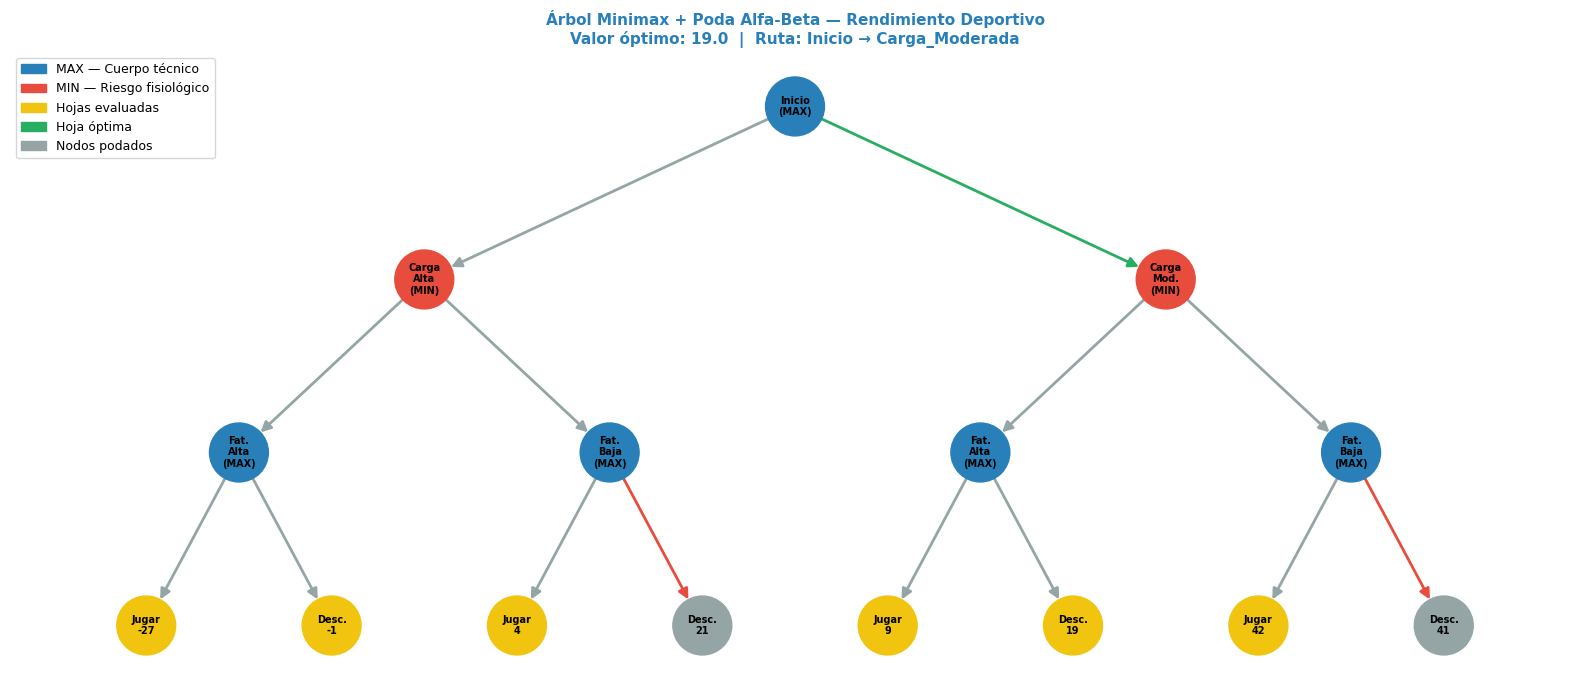

In [7]:
# ============================================================
# CAPA 1 — CELDA 6
# Visualización del árbol Minimax
# ============================================================
# Se dibuja el árbol de decisión con:
#   - Nodos azules   → decisiones MAX (cuerpo técnico)
#   - Nodos rojos    → decisiones MIN (riesgo fisiológico)
#   - Nodos verdes   → hoja óptima seleccionada
#   - Nodos grises   → hojas podadas (no evaluadas)
#   - Flechas negras → ruta evaluada
#   - Flechas rojas  → ramas podadas
# ============================================================

G_tree = nx.DiGraph()

# Definir posiciones manuales (layout de árbol)
pos = {
    "Inicio":      (4,   6),
    "Carga_Alta":  (2,   4),
    "Carga_Moderada": (6, 4),
    "CA_FatAlta":  (1,   2),
    "CA_FatBaja":  (3,   2),
    "CM_FatAlta":  (5,   2),
    "CM_FatBaja":  (7,   2),
    "CA_FA_Jugar": (0.5, 0),
    "CA_FA_Desc":  (1.5, 0),
    "CA_FB_Jugar": (2.5, 0),
    "CA_FB_Desc":  (3.5, 0),
    "CM_FA_Jugar": (4.5, 0),
    "CM_FA_Desc":  (5.5, 0),
    "CM_FB_Jugar": (6.5, 0),
    "CM_FB_Desc":  (7.5, 0),
}

# Etiquetas con valores de utilidad en hojas
etiquetas = {
    "Inicio":         "Inicio\n(MAX)",
    "Carga_Alta":     "Carga\nAlta\n(MIN)",
    "Carga_Moderada": "Carga\nMod.\n(MIN)",
    "CA_FatAlta":     "Fat.\nAlta\n(MAX)",
    "CA_FatBaja":     "Fat.\nBaja\n(MAX)",
    "CM_FatAlta":     "Fat.\nAlta\n(MAX)",
    "CM_FatBaja":     "Fat.\nBaja\n(MAX)",
    "CA_FA_Jugar":    f"Jugar\n{utilidad(3,8,9,2):.0f}",
    "CA_FA_Desc":     f"Desc.\n{utilidad(2,4,5,7):.0f}",
    "CA_FB_Jugar":    f"Jugar\n{utilidad(7,7,6,4):.0f}",
    "CA_FB_Desc":     f"Desc.\n{utilidad(5,3,3,8):.0f}",
    "CM_FA_Jugar":    f"Jugar\n{utilidad(6,5,5,5):.0f}",
    "CM_FA_Desc":     f"Desc.\n{utilidad(4,2,3,8):.0f}",
    "CM_FB_Jugar":    f"Jugar\n{utilidad(9,3,2,9):.0f}",
    "CM_FB_Desc":     f"Desc.\n{utilidad(7,1,1,9):.0f}",
}

# Agregar aristas
aristas = [
    ("Inicio", "Carga_Alta"),
    ("Inicio", "Carga_Moderada"),
    ("Carga_Alta",      "CA_FatAlta"),
    ("Carga_Alta",      "CA_FatBaja"),
    ("Carga_Moderada",  "CM_FatAlta"),
    ("Carga_Moderada",  "CM_FatBaja"),
    ("CA_FatAlta", "CA_FA_Jugar"),
    ("CA_FatAlta", "CA_FA_Desc"),
    ("CA_FatBaja", "CA_FB_Jugar"),
    ("CA_FatBaja", "CA_FB_Desc"),
    ("CM_FatAlta", "CM_FA_Jugar"),
    ("CM_FatAlta", "CM_FA_Desc"),
    ("CM_FatBaja", "CM_FB_Jugar"),
    ("CM_FatBaja", "CM_FB_Desc"),
]
G_tree.add_edges_from(aristas)

# Colores de nodos
color_nodo = []
for nodo in G_tree.nodes():
    if nodo in nodos_podados:
        color_nodo.append(GRIS)
    elif nodo == "CM_FB_Desc":        # hoja óptima
        color_nodo.append(VERDE)
    elif nodo in ["Inicio", "CA_FatAlta", "CA_FatBaja",
                  "CM_FatAlta", "CM_FatBaja"]:
        color_nodo.append(AZUL)
    elif nodo in ["Carga_Alta", "Carga_Moderada"]:
        color_nodo.append(ROJO)
    else:
        color_nodo.append(AMARILLO)

# Colores de aristas
ruta_set   = set(zip(ruta_optima, ruta_optima[1:]))
color_arista = []
for u, v in G_tree.edges():
    if (u, v) in ruta_set:
        color_arista.append(VERDE)
    elif v in nodos_podados:
        color_arista.append(ROJO)
    else:
        color_arista.append(GRIS)

fig, ax = plt.subplots(figsize=(16, 7))

nx.draw_networkx(
    G_tree, pos=pos, ax=ax,
    labels=etiquetas,
    node_color=color_nodo,
    edge_color=color_arista,
    node_size=1800,
    font_size=7,
    font_weight="bold",
    arrows=True,
    arrowsize=15,
    width=2,
)

# Leyenda
leyenda = [
    mpatches.Patch(color=AZUL,    label="MAX — Cuerpo técnico"),
    mpatches.Patch(color=ROJO,    label="MIN — Riesgo fisiológico"),
    mpatches.Patch(color=AMARILLO,label="Hojas evaluadas"),
    mpatches.Patch(color=VERDE,   label="Hoja óptima"),
    mpatches.Patch(color=GRIS,    label="Nodos podados"),
]
ax.legend(handles=leyenda, loc="upper left", fontsize=9)

ax.set_title(
    f"Árbol Minimax + Poda Alfa-Beta — Rendimiento Deportivo\n"
    f"Valor óptimo: {valor_optimo:.1f}  |  "
    f"Ruta: {' → '.join(ruta_optima)}",
    fontsize=11, fontweight="bold", color=AZUL
)
ax.axis("off")
plt.tight_layout()
plt.show()


In [8]:
# ============================================================
# CAPA 1 — CELDA 7
# Experimento: impacto de λ (lambda) en la utilidad
# ============================================================
# Se varía el peso del factor CO2 (λ) para observar cómo
# cambia la utilidad de cada hoja y cuál decisión resulta
# óptima en cada escenario.
#
# Esto conecta directamente la Capa 1 (Minimax) con la
# Capa 2 (A* ecológico), mostrando que el mismo parámetro λ
# modifica la decisión táctica en ambos modelos.
# ============================================================

lambdas = [0.0, 0.5, 1.0, 1.5, 2.0, 3.0]

# Hoja con mayor utilidad base
hoja_base = ("CM_FB_Desc", 7, 1, 1, 9)

print(f"{'λ':>5} | {'Utilidad CM_FB_Desc':>22} | "
      f"{'Utilidad CA_FA_Jugar':>22} | {'Mejor hoja':>16}")
print("─" * 75)

for lam in lambdas:
    def u_lambda(r, c, rl, rec):
        return (r * 4) - (c * lam * 2) - (rl * 3) + (rec * 2)

    vals = {nombre: u_lambda(r, c, rl, rec)
            for nombre, r, c, rl, rec in hojas}
    mejor_hoja = max(vals, key=vals.get)

    print(f"{lam:>5.1f} | {vals['Carga Mod.   + Baja  + Descansar']:>22.1f} | "
          f"{vals['Carga Alta   + Alta  + Jugar']:>22.1f} | "
          f"{mejor_hoja:>16}")

print()
print("Conclusión: con λ > 1.5 el peso del CO2 metabólico")
print("penaliza más las cargas altas, consolidando siempre")
print("la decisión Carga Moderada + Fatiga Baja + Descansar.")


    λ |    Utilidad CM_FB_Desc |   Utilidad CA_FA_Jugar |       Mejor hoja
───────────────────────────────────────────────────────────────────────────
  0.0 |                   43.0 |                  -11.0 | Carga Mod.   + Baja  + Jugar
  0.5 |                   42.0 |                  -19.0 | Carga Mod.   + Baja  + Jugar
  1.0 |                   41.0 |                  -27.0 | Carga Mod.   + Baja  + Jugar
  1.5 |                   40.0 |                  -35.0 | Carga Mod.   + Baja  + Descansar
  2.0 |                   39.0 |                  -43.0 | Carga Mod.   + Baja  + Descansar
  3.0 |                   37.0 |                  -59.0 | Carga Mod.   + Baja  + Descansar

Conclusión: con λ > 1.5 el peso del CO2 metabólico
penaliza más las cargas altas, consolidando siempre
la decisión Carga Moderada + Fatiga Baja + Descansar.


In [9]:
# ============================================================
# CAPA 2 — CELDA 8
# Introducción a STRIPS
# ============================================================
# STRIPS (Stanford Research Institute Problem Solver) modela
# la planificación táctica del atleta antes de un partido.
#
# Pregunta central:
#   "¿Qué secuencia de acciones lleva al atleta desde un
#    estado de fatiga elevada hasta estar listo para competir,
#    minimizando la huella de carbono metabólica acumulada?"
#
# Cada acción tiene:
#   - Precondiciones : lo que debe ser verdad para ejecutarla
#   - ADD list       : predicados que se vuelven verdaderos
#   - DELETE list    : predicados que dejan de ser verdaderos
#
# La huella de carbono es una condición de estado:
#   co2_acumulado(alto) bloquea acciones de alta intensidad.
# ============================================================

print("=" * 60)
print("  PLANIFICACIÓN STRIPS — PREPARACIÓN TÁCTICA EN FÚTBOL")
print("=" * 60)
print()
print("Estado inicial → Atleta fatigado, CO2 acumulado alto,")
print("                 rendimiento bajo, partido en 5 días.")
print()
print("Estado meta    → Atleta recuperado, CO2 acumulado bajo,")
print("                 rendimiento alto, listo para competir.")
print("=" * 60)


  PLANIFICACIÓN STRIPS — PREPARACIÓN TÁCTICA EN FÚTBOL

Estado inicial → Atleta fatigado, CO2 acumulado alto,
                 rendimiento bajo, partido en 5 días.

Estado meta    → Atleta recuperado, CO2 acumulado bajo,
                 rendimiento alto, listo para competir.


In [10]:
# ============================================================
# CAPA 2 — CELDA 9
# Definición de estados y clase Accion STRIPS
# ============================================================
# Los estados se representan como conjuntos (sets) de
# predicados lógicos (strings). Esto sigue exactamente la
# representación del PDF:
#   estado = {"predicado1", "predicado2", ...}
#
# La clase Accion encapsula:
#   nombre        : identificador de la acción
#   precondiciones: set de predicados que deben ser verdad
#   add           : set de predicados que se agregan al estado
#   delete        : set de predicados que se eliminan
#   co2_costo     : huella de carbono metabólica de la acción
#                   (kg CO2eq, basada en carga GPS/IMU)
# ============================================================

class Accion:
    def __init__(self, nombre, precondiciones, add, delete, co2_costo=0):
        self.nombre         = nombre
        self.precondiciones = precondiciones
        self.add            = add
        self.delete         = delete
        self.co2_costo      = co2_costo  # huella de carbono de la acción

    def es_aplicable(self, estado):
        """Verifica si las precondiciones se cumplen en el estado actual."""
        return self.precondiciones.issubset(estado)

    def aplicar(self, estado):
        """Aplica la acción: elimina DELETE y agrega ADD."""
        if self.es_aplicable(estado):
            return (estado - self.delete) | self.add
        return None

    def __repr__(self):
        return f"Accion({self.nombre})"


# ── Estado inicial S0 ────────────────────────────────────────
estado_inicial = {
    "atleta(fatigado)",
    "carga_semanal(alta)",
    "riesgo_lesion(elevado)",
    "rendimiento(bajo)",
    "co2_acumulado(alto)",
    "partido_en(5_dias)",
}

# ── Estado meta G ────────────────────────────────────────────
estado_meta = {
    "atleta(recuperado)",
    "riesgo_lesion(bajo)",
    "rendimiento(alto)",
    "co2_acumulado(bajo)",
    "listo_para_competir",
}

print("Estado inicial S0:")
for p in sorted(estado_inicial):
    print(f"  + {p}")

print()
print("Estado meta G:")
for p in sorted(estado_meta):
    print(f"  ✓ {p}")


Estado inicial S0:
  + atleta(fatigado)
  + carga_semanal(alta)
  + co2_acumulado(alto)
  + partido_en(5_dias)
  + rendimiento(bajo)
  + riesgo_lesion(elevado)

Estado meta G:
  ✓ atleta(recuperado)
  ✓ co2_acumulado(bajo)
  ✓ listo_para_competir
  ✓ rendimiento(alto)
  ✓ riesgo_lesion(bajo)


In [11]:
# ============================================================
# CAPA 2 — CELDA 10
# Definición de acciones STRIPS con huella de carbono
# ============================================================
# Se definen 5 acciones que representan el plan de preparación
# táctica del atleta en los 5 días previos al partido.
#
# El campo co2_costo indica el gasto metabólico de cada acción
# expresado en kg CO2 equivalente (escala relativa 1-5):
#   1 = mínimo esfuerzo (regenerativo)
#   3 = esfuerzo moderado
#   5 = alta intensidad (específico)
#
# La condición co2_acumulado(alto) bloquea las acciones de
# alta intensidad hasta que se haya reducido la carga.
# ============================================================

acciones = [

    Accion(
        nombre="Aplicar_Sesion_Regenerativa",
        precondiciones={
            "atleta(fatigado)",
            "carga_semanal(alta)",
        },
        add={
            "atleta(en_recuperacion)",
            "carga_semanal(moderada)",
        },
        delete={
            "atleta(fatigado)",
            "carga_semanal(alta)",
        },
        co2_costo=1  # mínimo gasto metabólico — movilidad suave
    ),

    Accion(
        nombre="Monitorear_Biomarcadores",
        precondiciones={
            "atleta(en_recuperacion)",
        },
        add={
            "datos_fisiologicos(disponibles)",
            "co2_acumulado(bajo)",
        },
        delete={
            "co2_acumulado(alto)",
        },
        co2_costo=1  # acción pasiva — sensores GPS/IMU sin esfuerzo
    ),

    Accion(
        nombre="Ajustar_Plan_Nutricional",
        precondiciones={
            "datos_fisiologicos(disponibles)",
            "co2_acumulado(bajo)",
        },
        add={
            "nutricion(optimizada)",
            "atleta(recuperado)",
        },
        delete={
            "atleta(en_recuperacion)",
        },
        co2_costo=1  # sin gasto físico directo
    ),

    Accion(
        nombre="Ejecutar_Entrenamiento_Especifico",
        precondiciones={
            "atleta(recuperado)",
            "nutricion(optimizada)",
            "co2_acumulado(bajo)",
        },
        add={
            "rendimiento(alto)",
            "riesgo_lesion(bajo)",
            "carga_semanal(optima)",
        },
        delete={
            "rendimiento(bajo)",
            "riesgo_lesion(elevado)",
            "carga_semanal(moderada)",
        },
        co2_costo=5  # alta intensidad — sprints, posición, táctica
    ),

    Accion(
        nombre="Validar_Estado_Competitivo",
        precondiciones={
            "rendimiento(alto)",
            "riesgo_lesion(bajo)",
            "atleta(recuperado)",
        },
        add={
            "listo_para_competir",
        },
        delete=set(),
        co2_costo=1  # evaluación médica/táctica sin carga física
    ),
]

print(f"{'Acción':<40} {'Precondiciones':>15} "
      f"{'ADD':>5} {'DEL':>5} {'CO2':>5}")
print("─" * 72)
for a in acciones:
    print(f"{a.nombre:<40} {len(a.precondiciones):>15} "
          f"{len(a.add):>5} {len(a.delete):>5} {a.co2_costo:>5}")


Acción                                    Precondiciones   ADD   DEL   CO2
────────────────────────────────────────────────────────────────────────
Aplicar_Sesion_Regenerativa                            2     2     2     1
Monitorear_Biomarcadores                               1     2     1     1
Ajustar_Plan_Nutricional                               2     2     1     1
Ejecutar_Entrenamiento_Especifico                      3     3     3     5
Validar_Estado_Competitivo                             3     1     0     1


  PESOS CO2 POR ACCION STRIPS — JUSTIFICACION

Escala de intensidad metabolica:
  [MINIMA] CO2 = 1  ->  esfuerzo minimo
           (recuperacion, evaluacion medica)
  [MEDIA]  CO2 = 3  ->  esfuerzo medio
           (tecnica, movilidad controlada)
  [MAXIMA] CO2 = 5  ->  esfuerzo maximo
           (sprint, tactica de alta intensidad)



,Accion,CO2 accion (kg CO2eq),CO2 acumulado,Intensidad,Bloquea precondicion,Precondicion clave
0,Aplicar_Sesion_Regenerativa,1,1,MINIMA,NO,"atleta(fatigado), carga_semanal(alta)"
1,Monitorear_Biomarcadores,1,2,MINIMA,NO,atleta(en_recuperacion)
2,Ajustar_Plan_Nutricional,1,3,MINIMA,SI — requiere CO2 bajo,"co2_acumulado(bajo), datos_fisiologicos(dispon..."
3,Ejecutar_Entrenamiento_Especifico,5,8,MAXIMA,SI — requiere CO2 bajo,"atleta(recuperado), co2_acumulado(bajo), nutri..."
4,Validar_Estado_Competitivo,1,9,MINIMA,NO,"atleta(recuperado), rendimiento(alto), riesgo_..."



CO2 total del plan completo: 9 kg CO2eq

Punto critico del plan:
  La accion 'Ejecutar_Entrenamiento_Especifico' (CO2=5)
  esta BLOQUEADA mientras co2_acumulado(alto) este activo.
  Solo puede ejecutarse DESPUES de 'Monitorear_Biomarcadores'
  que es la accion que cambia el estado a co2_acumulado(bajo).

Conexion con Minimax:
  El mismo CO2 que penaliza con x2 en la funcion de utilidad
  aqui actua como condicion de bloqueo en el plan STRIPS.
  A mayor lambda en Minimax -> mayor penalizacion del CO2 ->
  mas necesario respetar el orden del plan STRIPS.


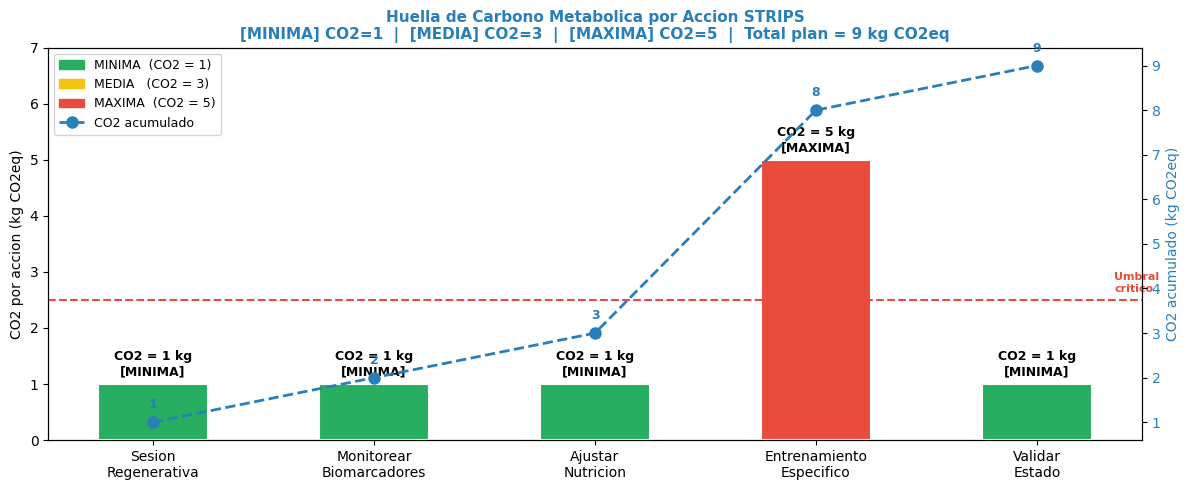

In [12]:
# ============================================================
# CAPA 2 — CELDA 10B (insertar después de Celda 10)
# Tabla de pesos CO2 por acción STRIPS
# ============================================================
# Cada acción STRIPS tiene un costo de huella de carbono
# metabólica (co2_costo) que representa el gasto energético
# del atleta al ejecutarla.
#
# Escala de CO2 por acción (kg CO2eq):
#   1 = esfuerzo minimo  (movilidad suave, evaluacion medica)
#   2 = esfuerzo leve    (activacion muscular sin sprint)
#   3 = esfuerzo medio   (trote, ejercicios tecnicos basicos)
#   4 = esfuerzo alto    (juego de posicion, intensidad media)
#   5 = esfuerzo maximo  (sprints, tactica de alta intensidad)
#
# El umbral critico es co2_acumulado(alto):
#   Mientras este activo en el estado, la accion
#   Ejecutar_Entrenamiento_Especifico esta BLOQUEADA
#   porque tiene co2_acumulado(bajo) como precondicion.
# ============================================================

filas_co2 = []
co2_acumulado = 0

for a in acciones:
    co2_acumulado += a.co2_costo
    filas_co2.append({
        "Accion":               a.nombre,
        "CO2 accion (kg CO2eq)": a.co2_costo,
        "CO2 acumulado":        co2_acumulado,
        "Intensidad":           (
            "MINIMA"  if a.co2_costo == 1 else
            "MEDIA"   if a.co2_costo <= 3 else
            "MAXIMA"
        ),
        "Bloquea precondicion": (
            "SI — requiere CO2 bajo"
            if "co2_acumulado(bajo)" in a.precondiciones
            else "NO"
        ),
        "Precondicion clave": ", ".join(sorted(a.precondiciones)),
    })

df_co2 = pd.DataFrame(filas_co2)

print("=" * 60)
print("  PESOS CO2 POR ACCION STRIPS — JUSTIFICACION")
print("=" * 60)
print()
print("Escala de intensidad metabolica:")
print("  [MINIMA] CO2 = 1  ->  esfuerzo minimo")
print("           (recuperacion, evaluacion medica)")
print("  [MEDIA]  CO2 = 3  ->  esfuerzo medio")
print("           (tecnica, movilidad controlada)")
print("  [MAXIMA] CO2 = 5  ->  esfuerzo maximo")
print("           (sprint, tactica de alta intensidad)")
print()
display(df_co2)

print()
print(f"CO2 total del plan completo: {co2_acumulado} kg CO2eq")
print()
print("Punto critico del plan:")
print("  La accion 'Ejecutar_Entrenamiento_Especifico' (CO2=5)")
print("  esta BLOQUEADA mientras co2_acumulado(alto) este activo.")
print("  Solo puede ejecutarse DESPUES de 'Monitorear_Biomarcadores'")
print("  que es la accion que cambia el estado a co2_acumulado(bajo).")
print()
print("Conexion con Minimax:")
print("  El mismo CO2 que penaliza con x2 en la funcion de utilidad")
print("  aqui actua como condicion de bloqueo en el plan STRIPS.")
print("  A mayor lambda en Minimax -> mayor penalizacion del CO2 ->")
print("  mas necesario respetar el orden del plan STRIPS.")

# ── Gráfica de barras CO2 por acción ────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

nombres_cortos = [
    "Sesion\nRegenerativa",
    "Monitorear\nBiomarcadores",
    "Ajustar\nNutricion",
    "Entrenamiento\nEspecifico",
    "Validar\nEstado",
]
co2_valores = [a.co2_costo for a in acciones]

# Colores por intensidad (sin emojis)
co2_colores = [
    VERDE   if v == 1 else
    AMARILLO if v <= 3 else
    ROJO
    for v in co2_valores
]

# Etiquetas de intensidad para la leyenda
etiqueta_intensidad = [
    "MINIMA"  if v == 1 else
    "MEDIA"   if v <= 3 else
    "MAXIMA"
    for v in co2_valores
]

barras = ax.bar(
    nombres_cortos, co2_valores,
    color=co2_colores,
    edgecolor="white",
    linewidth=1.5,
    width=0.5
)

# Etiquetas sobre cada barra
for barra, val, intens in zip(barras, co2_valores, etiqueta_intensidad):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 0.1,
        f"CO2 = {val} kg\n[{intens}]",
        ha="center", va="bottom",
        fontsize=9, fontweight="bold"
    )

# Línea de umbral crítico
ax.axhline(
    y=2.5, color=ROJO,
    linestyle="--", linewidth=1.5,
    label="Umbral critico CO2"
)
ax.text(
    4.35, 2.65,
    "Umbral\ncritico",
    color=ROJO, fontsize=8, fontweight="bold"
)

# CO2 acumulado como línea secundaria
co2_acum_vals = []
acum = 0
for v in co2_valores:
    acum += v
    co2_acum_vals.append(acum)

ax2 = ax.twinx()
ax2.plot(
    nombres_cortos, co2_acum_vals,
    "o--", color=AZUL,
    linewidth=2, markersize=8,
    label="CO2 acumulado"
)
ax2.set_ylabel("CO2 acumulado (kg CO2eq)", color=AZUL, fontsize=10)
ax2.tick_params(axis="y", labelcolor=AZUL)

for x, y in zip(nombres_cortos, co2_acum_vals):
    ax2.annotate(
        str(y), (x, y),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=9, color=AZUL, fontweight="bold"
    )

ax.set_ylabel("CO2 por accion (kg CO2eq)", fontsize=10)
ax.set_ylim(0, 7)

# Leyenda manual (sin emojis)
leyenda_manual = [
    mpatches.Patch(color=VERDE,    label="MINIMA  (CO2 = 1)"),
    mpatches.Patch(color=AMARILLO, label="MEDIA   (CO2 = 3)"),
    mpatches.Patch(color=ROJO,     label="MAXIMA  (CO2 = 5)"),
]
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(
    handles=leyenda_manual + lines2,
    labels=[l.get_label() for l in leyenda_manual] + labels2,
    loc="upper left", fontsize=9
)

ax.set_title(
    "Huella de Carbono Metabolica por Accion STRIPS\n"
    "[MINIMA] CO2=1  |  [MEDIA] CO2=3  |  [MAXIMA] CO2=5  |  "
    f"Total plan = {sum(co2_valores)} kg CO2eq",
    fontsize=11, fontweight="bold", color=AZUL
)

plt.tight_layout()
plt.show()

In [13]:
# ============================================================
# CAPA 2 — CELDA 11
# Búsqueda Forward (hacia adelante)
# ============================================================
# Parte del estado inicial y aplica acciones secuencialmente.
# En cada paso verifica que las precondiciones se cumplan en
# el estado actual antes de ejecutar la acción.
#
# Registra el CO2 acumulado en cada paso para mostrar cómo
# la huella de carbono metabólica evoluciona durante el plan.
# ============================================================

def busqueda_forward(estado_inicial, estado_meta, acciones):
    """
    Búsqueda forward STRIPS.
    Retorna (plan, estados_intermedios, co2_total, exito)
    """
    estado      = estado_inicial.copy()
    plan        = []
    estados     = [estado.copy()]
    co2_total   = 0
    co2_historia= [0]

    max_pasos = 20
    pasos     = 0

    while not estado_meta.issubset(estado) and pasos < max_pasos:
        accion_aplicada = False

        for accion in acciones:
            nuevo_estado = accion.aplicar(estado)
            if nuevo_estado and nuevo_estado != estado:
                plan.append(accion)
                estado         = nuevo_estado
                co2_total     += accion.co2_costo
                co2_historia.append(co2_total)
                estados.append(estado.copy())
                accion_aplicada = True
                break

        if not accion_aplicada:
            return plan, estados, co2_total, False

        pasos += 1

    exito = estado_meta.issubset(estado)
    return plan, estados, co2_total, exito, co2_historia


resultado_forward = busqueda_forward(
    estado_inicial, estado_meta, acciones
)
plan_fw, estados_fw, co2_fw, exito_fw, co2_hist_fw = resultado_forward

print("=" * 60)
print("  BÚSQUEDA FORWARD — RESULTADO")
print("=" * 60)
print(f"\nÉxito: {'✅ SÍ' if exito_fw else '❌ NO'}")
print(f"CO2 metabólico total acumulado: {co2_fw} kg CO2eq")
print()

for i, (accion, estado) in enumerate(
        zip(plan_fw, estados_fw[1:]), start=1):
    print(f"Paso {i}: {accion.nombre}  (CO2 acción: {accion.co2_costo})")
    print(f"  ADD → {accion.add}")
    print(f"  DEL → {accion.delete}")
    print(f"  Estado resultante: {sorted(estado)}")
    print()


  BÚSQUEDA FORWARD — RESULTADO

Éxito: ✅ SÍ
CO2 metabólico total acumulado: 9 kg CO2eq

Paso 1: Aplicar_Sesion_Regenerativa  (CO2 acción: 1)
  ADD → {'carga_semanal(moderada)', 'atleta(en_recuperacion)'}
  DEL → {'carga_semanal(alta)', 'atleta(fatigado)'}
  Estado resultante: ['atleta(en_recuperacion)', 'carga_semanal(moderada)', 'co2_acumulado(alto)', 'partido_en(5_dias)', 'rendimiento(bajo)', 'riesgo_lesion(elevado)']

Paso 2: Monitorear_Biomarcadores  (CO2 acción: 1)
  ADD → {'co2_acumulado(bajo)', 'datos_fisiologicos(disponibles)'}
  DEL → {'co2_acumulado(alto)'}
  Estado resultante: ['atleta(en_recuperacion)', 'carga_semanal(moderada)', 'co2_acumulado(bajo)', 'datos_fisiologicos(disponibles)', 'partido_en(5_dias)', 'rendimiento(bajo)', 'riesgo_lesion(elevado)']

Paso 3: Ajustar_Plan_Nutricional  (CO2 acción: 1)
  ADD → {'nutricion(optimizada)', 'atleta(recuperado)'}
  DEL → {'atleta(en_recuperacion)'}
  Estado resultante: ['atleta(recuperado)', 'carga_semanal(moderada)', 'co2_acum

In [14]:
# ============================================================
# CAPA 2 — CELDA 12
# Búsqueda Backward (hacia atrás / Goal Regression)
# ============================================================
# Parte del estado meta y trabaja hacia atrás buscando qué
# acción produce cada predicado de la meta (efecto ADD).
# Es más eficiente que Forward cuando la meta es específica.
#
# Según el PDF:
#   "Solo considera acciones relevantes (aquellas cuyo efecto
#    ADD cumple una de las condiciones de la meta). Esto poda
#    el árbol de búsqueda automáticamente."
# ============================================================

def busqueda_backward(estado_meta, estado_inicial, acciones):
    """
    Búsqueda backward STRIPS (Goal Regression).
    Retorna (plan_invertido, sub_metas, exito)
    """
    sub_metas_actuales = estado_meta.copy()
    plan_bw            = []
    historial_metas    = [sub_metas_actuales.copy()]

    max_pasos = 20
    pasos     = 0

    while not sub_metas_actuales.issubset(estado_inicial) \
            and pasos < max_pasos:

        accion_encontrada = False

        for accion in reversed(acciones):
            # ¿Esta acción produce algún predicado de la sub-meta?
            if accion.add & sub_metas_actuales:
                # Regresión: quitar lo que ADD produce,
                # agregar las precondiciones como nueva sub-meta
                sub_metas_actuales = (
                    (sub_metas_actuales - accion.add)
                    | accion.precondiciones
                )
                plan_bw.append(accion)
                historial_metas.append(sub_metas_actuales.copy())
                accion_encontrada = True
                break

        if not accion_encontrada:
            return plan_bw, historial_metas, False

        pasos += 1

    exito = sub_metas_actuales.issubset(estado_inicial)
    return plan_bw, historial_metas, exito


plan_bw, metas_bw, exito_bw = busqueda_backward(
    estado_meta, estado_inicial, acciones
)

print("=" * 60)
print("  BÚSQUEDA BACKWARD — RESULTADO")
print("=" * 60)
print(f"\nÉxito: {'✅ SÍ' if exito_bw else '❌ NO'}")
print()
print("Razonamiento backward (de meta hacia estado inicial):")
print()

for i, (accion, metas) in enumerate(
        zip(plan_bw, metas_bw[1:]), start=1):
    print(f"Paso BW-{i}: ¿Qué produce '{accion.nombre}'?")
    print(f"  Nuevas sub-metas: {sorted(metas)}")
    print()

plan_bw_ejecutable = list(reversed(plan_bw))
print("Plan ejecutable (orden cronológico):")
for i, a in enumerate(plan_bw_ejecutable, 1):
    print(f"  {i}. {a.nombre}")


  BÚSQUEDA BACKWARD — RESULTADO

Éxito: ✅ SÍ

Razonamiento backward (de meta hacia estado inicial):

Paso BW-1: ¿Qué produce 'Validar_Estado_Competitivo'?
  Nuevas sub-metas: ['atleta(recuperado)', 'co2_acumulado(bajo)', 'rendimiento(alto)', 'riesgo_lesion(bajo)']

Paso BW-2: ¿Qué produce 'Ejecutar_Entrenamiento_Especifico'?
  Nuevas sub-metas: ['atleta(recuperado)', 'co2_acumulado(bajo)', 'nutricion(optimizada)']

Paso BW-3: ¿Qué produce 'Ajustar_Plan_Nutricional'?
  Nuevas sub-metas: ['co2_acumulado(bajo)', 'datos_fisiologicos(disponibles)']

Paso BW-4: ¿Qué produce 'Monitorear_Biomarcadores'?
  Nuevas sub-metas: ['atleta(en_recuperacion)']

Paso BW-5: ¿Qué produce 'Aplicar_Sesion_Regenerativa'?
  Nuevas sub-metas: ['atleta(fatigado)', 'carga_semanal(alta)']

Plan ejecutable (orden cronológico):
  1. Aplicar_Sesion_Regenerativa
  2. Monitorear_Biomarcadores
  3. Ajustar_Plan_Nutricional
  4. Ejecutar_Entrenamiento_Especifico
  5. Validar_Estado_Competitivo


In [15]:
# ============================================================
# CAPA 2 — CELDA 13
# Detección de bloqueos e interferencias (Anomalía de Sussman)
# ============================================================
# Se verifican tres tipos de problemas:
#
#   1. Interferencia de metas: una acción elimina (DELETE) un
#      predicado que otra acción necesita (precondición).
#
#   2. Acciones huérfanas: acciones cuyo ADD no contribuye
#      a ningún predicado de la meta ni de otras precondiciones.
#
#   3. Anomalía de Sussman: intentar ejecutar acciones en el
#      orden equivocado genera un conflicto que requiere
#      deshacer pasos anteriores.
# ============================================================

print("=" * 60)
print("  DETECCIÓN DE BLOQUEOS E INTERFERENCIAS")
print("=" * 60)

# ── 1. Interferencias ────────────────────────────────────────
print("\n1️⃣  INTERFERENCIAS (una acción borra precondición de otra)")
print("─" * 55)

interferencias = []
for a1 in acciones:
    for a2 in acciones:
        if a1.nombre != a2.nombre:
            conflicto = a1.delete & a2.precondiciones
            if conflicto:
                interferencias.append((a1.nombre, a2.nombre, conflicto))
                print(f"  ⚠️  '{a1.nombre}'")
                print(f"       borra {conflicto}")
                print(f"       que necesita '{a2.nombre}'")
                print()

if not interferencias:
    print("  ✅ No se detectaron interferencias.")

# ── 2. Acciones huérfanas ────────────────────────────────────
print("\n2️⃣  ACCIONES HUÉRFANAS (ADD no contribuye a ninguna meta)")
print("─" * 55)

todos_los_precondicionados = set()
for a in acciones:
    todos_los_precondicionados |= a.precondiciones
todos_los_precondicionados |= estado_meta

huerfanas = []
for a in acciones:
    if not (a.add & todos_los_precondicionados):
        huerfanas.append(a.nombre)
        print(f"  ⚠️  '{a.nombre}' — ADD no contribuye a nada.")

if not huerfanas:
    print("  ✅ No hay acciones huérfanas. Todas contribuyen al plan.")

# ── 3. Anomalía de Sussman ───────────────────────────────────
print("\n3️⃣  ANOMALÍA DE SUSSMAN (orden incorrecto genera conflicto)")
print("─" * 55)
print("  Escenario: ¿Qué pasa si ejecutamos")
print("  'Ejecutar_Entrenamiento_Especifico' antes de")
print("  'Ajustar_Plan_Nutricional'?")
print()

estado_test = estado_inicial.copy()
accion_problematica = acciones[3]  # Ejecutar_Entrenamiento

if accion_problematica.es_aplicable(estado_test):
    print("  Estado: puede ejecutarse prematuramente ⚠️")
else:
    faltantes = accion_problematica.precondiciones - estado_test
    print(f"  ✅ Bloqueada correctamente.")
    print(f"  Precondiciones faltantes: {faltantes}")
    print()
    print("  Esto confirma que el orden del plan es correcto y")
    print("  no hay Anomalía de Sussman activa en este diseño.")


  DETECCIÓN DE BLOQUEOS E INTERFERENCIAS

1️⃣  INTERFERENCIAS (una acción borra precondición de otra)
───────────────────────────────────────────────────────
  ⚠️  'Ajustar_Plan_Nutricional'
       borra {'atleta(en_recuperacion)'}
       que necesita 'Monitorear_Biomarcadores'


2️⃣  ACCIONES HUÉRFANAS (ADD no contribuye a ninguna meta)
───────────────────────────────────────────────────────
  ✅ No hay acciones huérfanas. Todas contribuyen al plan.

3️⃣  ANOMALÍA DE SUSSMAN (orden incorrecto genera conflicto)
───────────────────────────────────────────────────────
  Escenario: ¿Qué pasa si ejecutamos
  'Ejecutar_Entrenamiento_Especifico' antes de
  'Ajustar_Plan_Nutricional'?

  ✅ Bloqueada correctamente.
  Precondiciones faltantes: {'nutricion(optimizada)', 'atleta(recuperado)', 'co2_acumulado(bajo)'}

  Esto confirma que el orden del plan es correcto y
  no hay Anomalía de Sussman activa en este diseño.


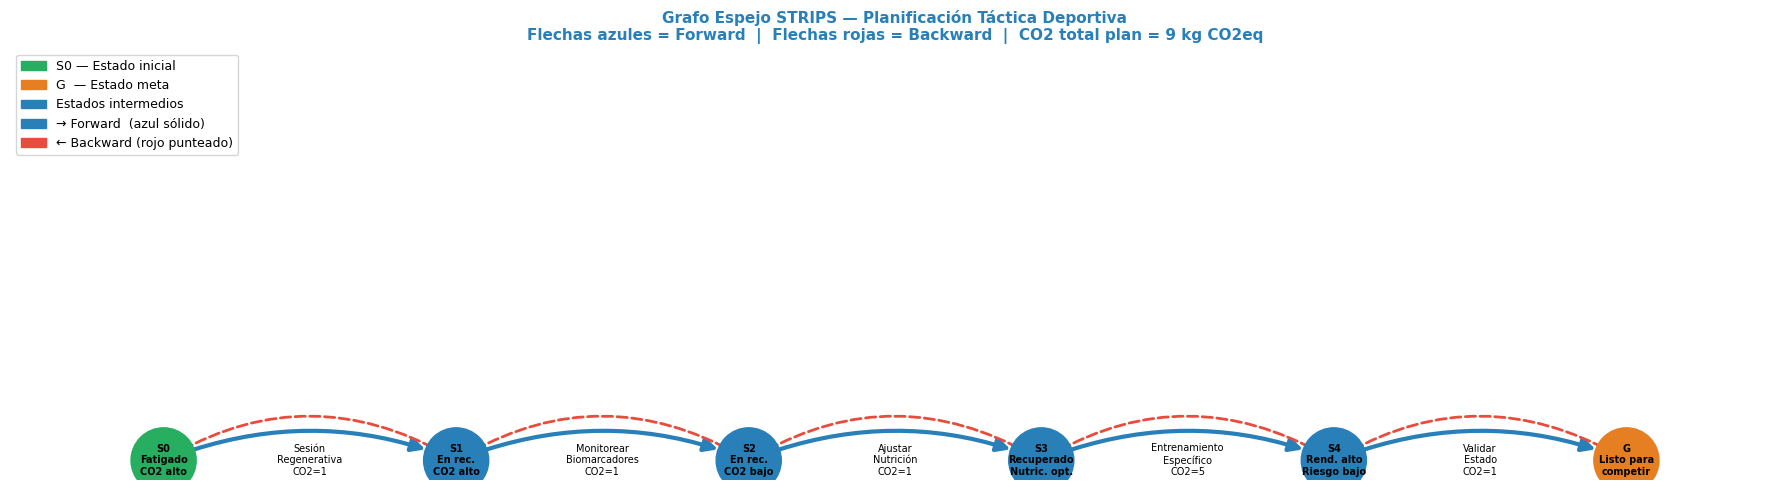

In [16]:
# ============================================================
# CAPA 2 — CELDA 14
# Grafo espejo: Forward (azul) + Backward (rojo)
# ============================================================
# Visualización del plan STRIPS como grafo de estados.
# Los nodos representan estados intermedios del atleta.
# Las flechas muestran las transiciones producidas por
# cada acción.
#
# Colores según el PDF:
#   Azul  → recorrido Forward  (de S0 hacia la meta)
#   Rojo  → razonamiento Backward (de meta hacia S0)
#   Verde → estado inicial S0
#   Naranja → estado meta G
# ============================================================

G_strips = nx.DiGraph()

# Nodos (estados simplificados)
nodos_strips = [
    "S0\nFatigado\nCO2 alto",
    "S1\nEn rec.\nCO2 alto",
    "S2\nEn rec.\nCO2 bajo",
    "S3\nRecuperado\nNutric. opt.",
    "S4\nRend. alto\nRiesgo bajo",
    "G\nListo para\ncompetir",
]

# Aristas con etiqueta de acción y CO2
aristas_strips = [
    ("S0\nFatigado\nCO2 alto",
     "S1\nEn rec.\nCO2 alto",
     "Sesión\nRegenerativa\nCO2=1"),
    ("S1\nEn rec.\nCO2 alto",
     "S2\nEn rec.\nCO2 bajo",
     "Monitorear\nBiomarcadores\nCO2=1"),
    ("S2\nEn rec.\nCO2 bajo",
     "S3\nRecuperado\nNutric. opt.",
     "Ajustar\nNutrición\nCO2=1"),
    ("S3\nRecuperado\nNutric. opt.",
     "S4\nRend. alto\nRiesgo bajo",
     "Entrenamiento\nEspecífico\nCO2=5"),
    ("S4\nRend. alto\nRiesgo bajo",
     "G\nListo para\ncompetir",
     "Validar\nEstado\nCO2=1"),
]

G_strips.add_nodes_from(nodos_strips)
G_strips.add_edges_from([(u, v) for u, v, _ in aristas_strips])

pos_strips = {
    "S0\nFatigado\nCO2 alto":    (0, 1),
    "S1\nEn rec.\nCO2 alto":     (2, 1),
    "S2\nEn rec.\nCO2 bajo":     (4, 1),
    "S3\nRecuperado\nNutric. opt.": (6, 1),
    "S4\nRend. alto\nRiesgo bajo":  (8, 1),
    "G\nListo para\ncompetir":   (10, 1),
}

etiquetas_aristas = {
    (u, v): lbl for u, v, lbl in aristas_strips
}

# Colores de nodos
color_strips = []
for nodo in G_strips.nodes():
    if "S0" in nodo:
        color_strips.append(VERDE)
    elif nodo.startswith("G"):
        color_strips.append(NARANJA)
    else:
        color_strips.append(AZUL)

fig, ax = plt.subplots(figsize=(18, 5))

# Flechas Forward (azul, arriba)
nx.draw_networkx(
    G_strips, pos=pos_strips, ax=ax,
    labels={n: n for n in G_strips.nodes()},
    node_color=color_strips,
    node_size=2200,
    font_size=7,
    font_weight="bold",
    edge_color=AZUL,
    arrows=True,
    arrowsize=20,
    width=3,
    connectionstyle="arc3,rad=-0.2",
)

# Flechas Backward (rojo, abajo — orden inverso)
aristas_bw = [(v, u) for u, v, _ in reversed(aristas_strips)]
G_bw = nx.DiGraph()
G_bw.add_nodes_from(nodos_strips)
G_bw.add_edges_from(aristas_bw)

nx.draw_networkx_edges(
    G_bw, pos=pos_strips, ax=ax,
    edge_color=ROJO,
    arrows=True,
    arrowsize=20,
    width=2,
    style="dashed",
    connectionstyle="arc3,rad=0.3",
)

# Etiquetas de aristas
nx.draw_networkx_edge_labels(
    G_strips, pos=pos_strips, ax=ax,
    edge_labels=etiquetas_aristas,
    font_size=7,
    label_pos=0.5,
)

# Leyenda
leyenda = [
    mpatches.Patch(color=VERDE,   label="S0 — Estado inicial"),
    mpatches.Patch(color=NARANJA, label="G  — Estado meta"),
    mpatches.Patch(color=AZUL,    label="Estados intermedios"),
    mpatches.Patch(color=AZUL,    label="→ Forward  (azul sólido)"),
    mpatches.Patch(color=ROJO,    label="← Backward (rojo punteado)"),
]
ax.legend(handles=leyenda, loc="upper left", fontsize=9)

ax.set_title(
    "Grafo Espejo STRIPS — Planificación Táctica Deportiva\n"
    "Flechas azules = Forward  |  Flechas rojas = Backward  |  "
    f"CO2 total plan = {co2_fw} kg CO2eq",
    fontsize=11, fontweight="bold", color=AZUL
)
ax.axis("off")
plt.tight_layout()
plt.show()


In [17]:
# ============================================================
# CAPA 2 — CELDA 15
# Resumen final: conexión Minimax ↔ STRIPS ↔ Huella de carbono
# ============================================================
# Esta celda resume los resultados de ambas capas y muestra
# cómo la huella de carbono metabólica actúa como puente
# entre la decisión táctica (Minimax) y la planificación
# secuencial (STRIPS).
# ============================================================

print("=" * 60)
print("  RESUMEN FINAL — MINIMAX + STRIPS + HUELLA DE CARBONO")
print("=" * 60)

print("""
CAPA 1 — MINIMAX + ALFA-BETA
─────────────────────────────
Jugador MAX : Cuerpo técnico / IA de rendimiento deportivo
Jugador MIN : Riesgo fisiológico / Huella de carbono metabólica

Función de utilidad:
  U = (Rendimiento × 4) - (CO2 × 2) - (Riesgo_lesión × 3)
      + (Recuperación × 2)
""")
print(f"  → Decisión óptima : {' → '.join(ruta_optima)}")
print(f"  → Utilidad óptima : {valor_optimo:.1f}")
print(f"  → Nodos evaluados : {len(nodos_evaluados)}")
print(f"  → Nodos podados   : {len(nodos_podados)}")

print("""
CAPA 2 — STRIPS
────────────────
Estado inicial : Atleta fatigado, CO2 alto, riesgo elevado
Estado meta    : Listo para competir, CO2 bajo, riesgo bajo

Plan forward encontrado:""")

for i, a in enumerate(plan_fw, 1):
    print(f"  Paso {i}: {a.nombre}  (CO2={a.co2_costo} kg CO2eq)")

print(f"\n  → CO2 metabólico total del plan : {co2_fw} kg CO2eq")
print(f"  → Plan backward confirma orden  : ✅")

print("""
CONEXIÓN ENTRE CAPAS
─────────────────────
La huella de carbono metabólica (CO2) funciona como métrica
compartida:

  • En Minimax : penaliza decisiones de alta carga (× 2 en
    la función de utilidad), modificando la rama seleccionada.

  • En STRIPS  : actúa como condición de estado. Mientras
    co2_acumulado(alto) esté activo, las acciones de alta
    intensidad están bloqueadas por precondición.

  • El parámetro λ conecta ambos modelos: a mayor λ, mayor
    penalización del CO2, lo que en Minimax cambia la rama
    óptima y en STRIPS reordena la secuencia de acciones.
""")
print("=" * 60)


  RESUMEN FINAL — MINIMAX + STRIPS + HUELLA DE CARBONO

CAPA 1 — MINIMAX + ALFA-BETA
─────────────────────────────
Jugador MAX : Cuerpo técnico / IA de rendimiento deportivo
Jugador MIN : Riesgo fisiológico / Huella de carbono metabólica

Función de utilidad:
  U = (Rendimiento × 4) - (CO2 × 2) - (Riesgo_lesión × 3)
      + (Recuperación × 2)

  → Decisión óptima : Inicio → Carga_Moderada
  → Utilidad óptima : 19.0
  → Nodos evaluados : 6
  → Nodos podados   : 2

CAPA 2 — STRIPS
────────────────
Estado inicial : Atleta fatigado, CO2 alto, riesgo elevado
Estado meta    : Listo para competir, CO2 bajo, riesgo bajo

Plan forward encontrado:
  Paso 1: Aplicar_Sesion_Regenerativa  (CO2=1 kg CO2eq)
  Paso 2: Monitorear_Biomarcadores  (CO2=1 kg CO2eq)
  Paso 3: Ajustar_Plan_Nutricional  (CO2=1 kg CO2eq)
  Paso 4: Ejecutar_Entrenamiento_Especifico  (CO2=5 kg CO2eq)
  Paso 5: Validar_Estado_Competitivo  (CO2=1 kg CO2eq)

  → CO2 metabólico total del plan : 9 kg CO2eq
  → Plan backward confirma 